In [83]:
# # Análise Exploratória e Modelagem Preditiva da Frota Eletrificada em São Paulo
# *Autor: Felipe Ferreira Tavares*
#
# Este notebook consolida dados históricos obtidos via web scraping da Senatran sobre a
# evolução de veículos híbridos e elétricos no município de São Paulo entre 2024 e 2026.

In [84]:
from pathlib import Path
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression

import matplotlib.pyplot as plt

# Força o Plotly a salvar uma cópia estática em PNG dentro do arquivo do notebook
import plotly.io as pio
pio.renderers.default = "png" # ou "svg"

In [85]:
ANOS = ["2024", "2025", "2026"]
MESES = [
    "Janeiro", "Fevereiro", "Março", "Abril", "Maio", "Junho",
    "Julho", "Agosto", "Setembro", "Outubro", "Novembro", "Dezembro"
]

mapa_meses_num = {
    "Janeiro": 1, "Fevereiro": 2, "Março": 3, "Maro": 3, "Abril": 4,
    "Maio": 5, "Junho": 6, "Julho": 7, "Agosto": 8, "Setembro": 9,
    "Outubro": 10, "Novembro": 11, "Dezembro": 12
}

combustiveis_interesse = [
    "ELETRICO", "ELETRICO/FONTE EXTERNA", "ELETRICO/FONTE INTERNA",
    "HIBRIDO", "HIBRIDO PLUG-IN", "GASOLINA/ELETRICO"
]

# 1. VEÍCULOS 100% ELÉTRICOS (Bateria / Emissão Zero)
eletricos_puros_list = [
    "ELETRICO",
    "ELETRICO/FONTE EXTERNA",
    "ELETRICO/FONTE INTERNA"
]

# 2. VEÍCULOS HÍBRIDOS (Combinam combustão com eletrificação)
hibridos_list = [
    "DIESEL/ELETRICO",
    "ETANOL/ELETRICO",
    "GASOLINA/ALCOOL/ELETRICO",
    "GASOLINA/ELETRICO",
    "HIBRIDO",
    "HIBRIDO PLUG-IN"
]

# 3. VEÍCULOS A COMBUSTÃO TRADICIONAL / FÓSSIL / RENOVÁVEL
combustao_pura_list = [
    "ALCOOL",
    "ALCOOL/GAS NATURAL COMBUSTIVEL",
    "ALCOOL/GAS NATURAL VEICULAR",
    "ALCOOL/GASOLINA",
    "DIESEL",
    "DIESEL/GAS NATURAL COMBUSTIVEL",
    "DIESEL/GAS NATURAL VEICULAR",
    "GAS METANO",
    "GAS NATURAL VEICULAR",
    "GAS/NATURAL/LIQUEFEITO",
    "GASOGENIO",
    "GASOL/GAS NATURAL COMBUSTIVEL",
    "GASOLINA",
    "GASOLINA/ALCOOL/GAS NATURAL",
    "GASOLINA/GAS NATURAL VEICULAR"
]


## 1. Consolidação e Engenharia de Dados (ETL Local)

In [86]:
# Um looping de looping sobre cada ano e cada mês para gerar os nomes dos arquivos dentro da pasta data.
arquivos_projeto = []
for ano in ANOS:
    for mes in MESES:
        arquivos_projeto.append({
            "nome_identificador": f"{mes}_{ano}",
            "nome_arquivo": f"D_Frota_por_UF_Municipio_COMBUSTIVEL_{mes}_{ano}.xlsx"
        })

pasta_data = Path.cwd().parent / "data" # Directory of Data.
lista_dfs = []


# For loop para iterar sobre os paths/nomes de arquivos gerados, para procurar dentro de Data;
for item in arquivos_projeto:
    caminho_completo = pasta_data / item["nome_arquivo"]
    if caminho_completo.exists():
        df_temporario = pd.read_excel(caminho_completo)
        df_temporario["origem_dados"] = item["nome_identificador"]
        
        # Extraindo dimensões de tempo para facilitar análises avançadas
        df_temporario["Ano_Ref"] = int(item["nome_identificador"].split("_")[1])
        df_temporario["Mes_Nome"] = item["nome_identificador"].split("_")[0]
        df_temporario["Mes_Ref"] = df_temporario["Mes_Nome"].map(mapa_meses_num)
        
        lista_dfs.append(df_temporario)

In [87]:
if lista_dfs:
    df_final = pd.concat(lista_dfs, ignore_index=True)
    # Filtro focado estritamente no município de interesse e escopo elétrico/híbrido
    eletricos_sp = df_final[
        (df_final["Município"] == "SAO PAULO") & 
        (df_final["Combustível Veículo"].isin(eletricos_puros_list))
    ].copy()
        
    hibridos_sp = df_final[
        (df_final["Município"] == "SAO PAULO") & 
        (df_final["Combustível Veículo"].isin(hibridos_list))
    ].copy()
    
    combustao_pura_sp = df_final[
        (df_final["Município"] == "SAO PAULO") & 
        (df_final["Combustível Veículo"].isin(combustao_pura_list))
    ].copy()
    
    print(f"✓ Sucesso! {len(lista_dfs)} arquivos consolidados.")
else:
    print("⚠️ Nenhum arquivo carregado. Verifique os caminhos.")

✓ Sucesso! 30 arquivos consolidados.


2.1 Análise de Aceleração do Mercado (Métricas de Crescimento) - Elétrico

In [88]:
evolucao_geral_eletrico = (
    eletricos_sp.groupby(["Ano_Ref", "Mes_Ref", "Mes_Nome"])["Qtd. Veículos"]
    .sum()
    .reset_index()
    .sort_values(["Ano_Ref", "Mes_Ref"])
).copy()

# Cálculo da variação percentual mês a mês (MoM)
evolucao_geral_eletrico["Crescimento_MoM_%"] = (
    evolucao_geral_eletrico["Qtd. Veículos"].pct_change() * 100
)

# CORREÇÃO: Usando pct_change com periods=12 para olhar 12 meses atrás (YoY)
evolucao_geral_eletrico["Crescimento_YoY_%"] = (
    evolucao_geral_eletrico["Qtd. Veículos"].pct_change(periods=12) * 100
)

print(
    "Tabela de Evolução da Frota de Elétricos/Híbridos com Métricas de"
    " Aceleração:"
)
print(
    evolucao_geral_eletrico[
        [
            "Ano_Ref",
            "Mes_Nome",
            "Qtd. Veículos",
            "Crescimento_MoM_%",
            "Crescimento_YoY_%",
        ]
    ].tail(6)
)

Tabela de Evolução da Frota de Elétricos/Híbridos com Métricas de Aceleração:
    Ano_Ref   Mes_Nome  Qtd. Veículos  Crescimento_MoM_%  Crescimento_YoY_%
24     2026    Janeiro          30288           3.357903          48.151047
25     2026  Fevereiro          31238           3.136556          44.486586
26     2026      Março          33256           6.460081          45.757363
27     2026      Abril          35724           7.421217          52.581899
28     2026       Maio          37540           5.083417          54.804124
29     2026      Junho          40349           7.482685          61.415370


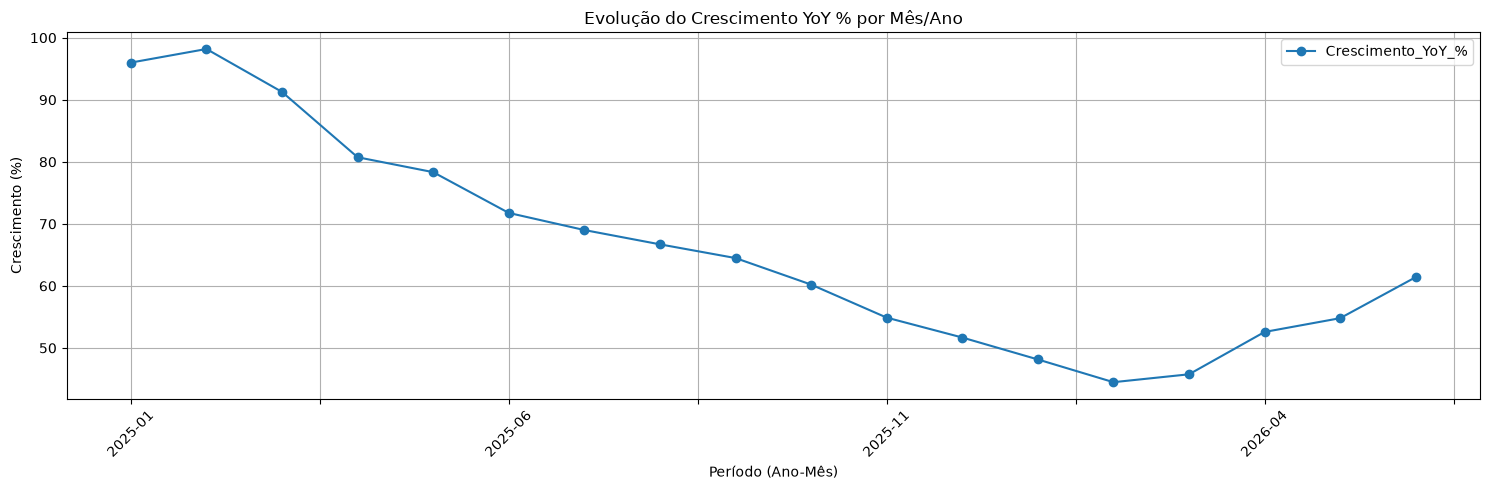

In [89]:
# 1. Criando a coluna de Data combinando Ano e Mês
# O zfill(2) garante que o mês fique com dois dígitos (ex: 2024-01 em vez de 2024-1)
evolucao_geral_eletrico['Data'] = (
    evolucao_geral_eletrico['Ano_Ref'].astype(str) + '-' + 
    evolucao_geral_eletrico['Mes_Ref'].astype(str).str.zfill(2)
)

# 2. Filtrando os valores nulos (Missing values de 2024) para o gráfico não quebrar
# Substitua pelo nome real do seu dataframe se não for 'evolucao_geral'
df_plot = evolucao_geral_eletrico.dropna(subset=['Crescimento_YoY_%'])

# 3. Plotando o gráfico esticado horizontalmente
df_plot.plot(
    x='Data', 
    y='Crescimento_YoY_%', 
    figsize=(15, 5),  # Bem esticado horizontalmente
    marker='o',       # Adiciona pontinhos em cada mês
    grid=True         # Adiciona linhas de grade para facilitar a leitura
)

# 4. Ajustes visuais para os meses não se sobreporem no eixo X
plt.title('Evolução do Crescimento YoY % por Mês/Ano')
plt.xlabel('Período (Ano-Mês)')
plt.ylabel('Crescimento (%)')
plt.xticks(rotation=45) # Rotaciona os textos do eixo X em 45 graus
plt.tight_layout()      # Garante que nenhum texto seja cortado nas bordas

plt.show()


2.2 Análise de Aceleração do Mercado (Métricas de Crescimento) - Híbrido

In [90]:
evolucao_geral_hibridos = (
    hibridos_sp.groupby(["Ano_Ref", "Mes_Ref", "Mes_Nome"])["Qtd. Veículos"]
    .sum()
    .reset_index()
    .sort_values(["Ano_Ref", "Mes_Ref"])
).copy()

# Cálculo da variação percentual mês a mês (MoM)
evolucao_geral_hibridos["Crescimento_MoM_%"] = (
    evolucao_geral_hibridos["Qtd. Veículos"].pct_change() * 100
)

# CORREÇÃO: Usando pct_change com periods=12 para olhar 12 meses atrás (YoY)
evolucao_geral_hibridos["Crescimento_YoY_%"] = (
    evolucao_geral_hibridos["Qtd. Veículos"].pct_change(periods=12) * 100
)

print(
    "Tabela de Evolução da Frota de Elétricos/Híbridos com Métricas de"
    " Aceleração:"
)
print(
    evolucao_geral_hibridos[
        [
            "Ano_Ref",
            "Mes_Nome",
            "Qtd. Veículos",
            "Crescimento_MoM_%",
            "Crescimento_YoY_%",
        ]
    ].tail(6)
)

Tabela de Evolução da Frota de Elétricos/Híbridos com Métricas de Aceleração:
    Ano_Ref   Mes_Nome  Qtd. Veículos  Crescimento_MoM_%  Crescimento_YoY_%
24     2026    Janeiro          83566           3.341413          53.642214
25     2026  Fevereiro          86268           3.233372          53.882378
26     2026      Março          89662           3.934251          54.453842
27     2026      Abril          93222           3.970467          55.253560
28     2026       Maio          97149           4.212525          56.248392
29     2026      Junho         101326           4.299581          57.529306


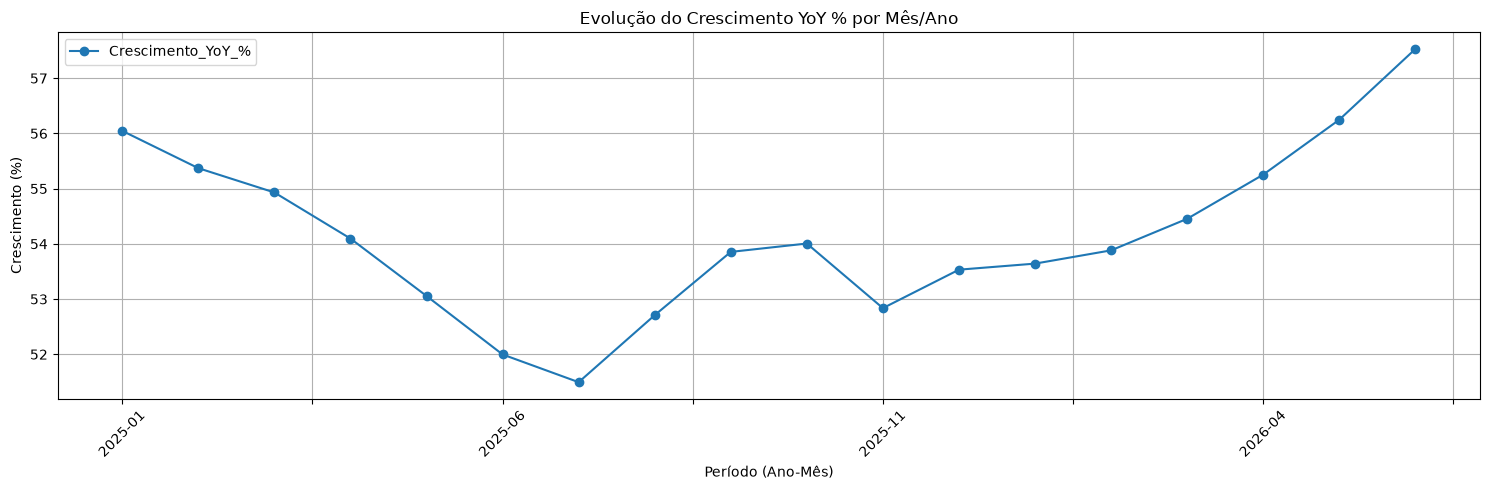

In [91]:
# 1. Criando a coluna de Data combinando Ano e Mês
# O zfill(2) garante que o mês fique com dois dígitos (ex: 2024-01 em vez de 2024-1)
evolucao_geral_hibridos['Data'] = (
    evolucao_geral_hibridos['Ano_Ref'].astype(str) + '-' + 
    evolucao_geral_hibridos['Mes_Ref'].astype(str).str.zfill(2)
)

# 2. Filtrando os valores nulos (Missing values de 2024) para o gráfico não quebrar
# Substitua pelo nome real do seu dataframe se não for 'evolucao_geral'
df_plot = evolucao_geral_hibridos.dropna(subset=['Crescimento_YoY_%'])

# 3. Plotando o gráfico esticado horizontalmente
df_plot.plot(
    x='Data', 
    y='Crescimento_YoY_%', 
    figsize=(15, 5),  # Bem esticado horizontalmente
    marker='o',       # Adiciona pontinhos em cada mês
    grid=True         # Adiciona linhas de grade para facilitar a leitura
)

# 4. Ajustes visuais para os meses não se sobreporem no eixo X
plt.title('Evolução do Crescimento YoY % por Mês/Ano')
plt.xlabel('Período (Ano-Mês)')
plt.ylabel('Crescimento (%)')
plt.xticks(rotation=45) # Rotaciona os textos do eixo X em 45 graus
plt.tight_layout()      # Garante que nenhum texto seja cortado nas bordas

plt.show()


2.3 Análise de Aceleração do Mercado (Métricas de Crescimento) - Combustão

In [92]:
evolucao_geral_combustao = (
    combustao_pura_sp.groupby(["Ano_Ref", "Mes_Ref", "Mes_Nome"])["Qtd. Veículos"]
    .sum()
    .reset_index()
    .sort_values(["Ano_Ref", "Mes_Ref"])
).copy()

# Cálculo da variação percentual mês a mês (MoM)
evolucao_geral_combustao["Crescimento_MoM_%"] = (
    evolucao_geral_combustao["Qtd. Veículos"].pct_change() * 100
)

# CORREÇÃO: Usando pct_change com periods=12 para olhar 12 meses atrás (YoY)
evolucao_geral_combustao["Crescimento_YoY_%"] = (
    evolucao_geral_combustao["Qtd. Veículos"].pct_change(periods=12) * 100
)

print(
    "Tabela de Evolução da Frota de Elétricos/Híbridos com Métricas de"
    " Aceleração:"
)
print(
    evolucao_geral_combustao[
        [
            "Ano_Ref",
            "Mes_Nome",
            "Qtd. Veículos",
            "Crescimento_MoM_%",
            "Crescimento_YoY_%",
        ]
    ].tail(6)
)

Tabela de Evolução da Frota de Elétricos/Híbridos com Métricas de Aceleração:
    Ano_Ref   Mes_Nome  Qtd. Veículos  Crescimento_MoM_%  Crescimento_YoY_%
24     2026    Janeiro        9714820           0.119445           1.822803
25     2026  Fevereiro        9726429           0.119498           1.713216
26     2026      Março        9744312           0.183860           1.700124
27     2026      Abril        9762025           0.181778           1.620532
28     2026       Maio        9779649           0.180536           1.596441
29     2026      Junho        9797555           0.183095           1.614676


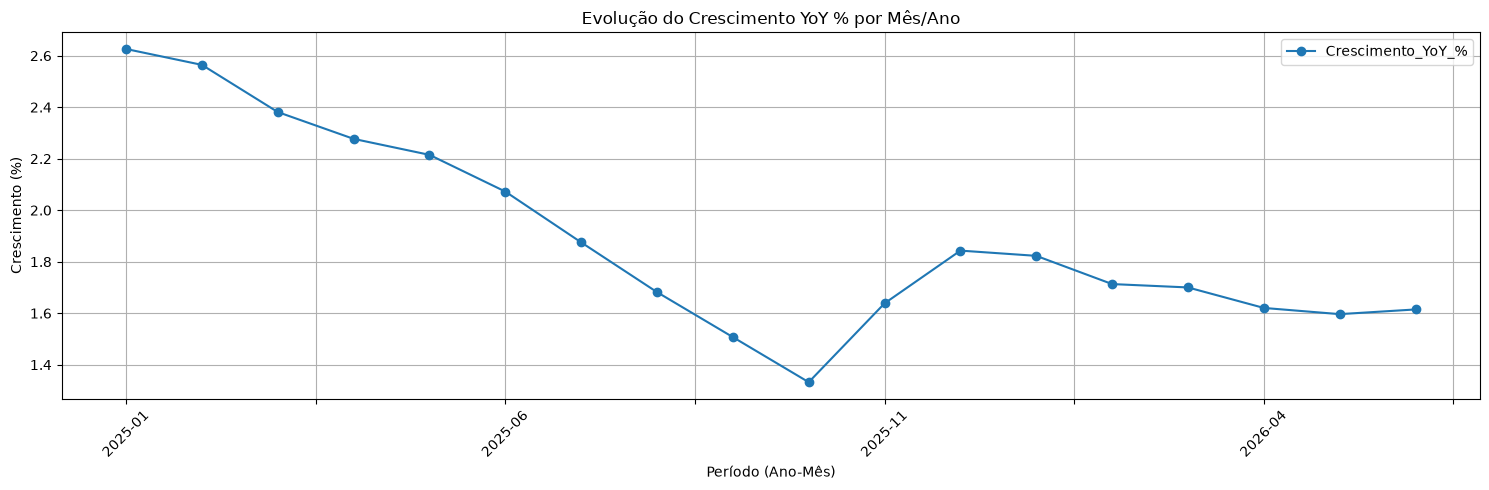

In [93]:
# 1. Criando a coluna de Data combinando Ano e Mês
# O zfill(2) garante que o mês fique com dois dígitos (ex: 2024-01 em vez de 2024-1)
evolucao_geral_combustao['Data'] = (
    evolucao_geral_combustao['Ano_Ref'].astype(str) + '-' + 
    evolucao_geral_combustao['Mes_Ref'].astype(str).str.zfill(2)
)

# 2. Filtrando os valores nulos (Missing values de 2024) para o gráfico não quebrar
# Substitua pelo nome real do seu dataframe se não for 'evolucao_geral'
df_plot = evolucao_geral_combustao.dropna(subset=['Crescimento_YoY_%'])

# 3. Plotando o gráfico esticado horizontalmente
df_plot.plot(
    x='Data', 
    y='Crescimento_YoY_%', 
    figsize=(15, 5),  # Bem esticado horizontalmente
    marker='o',       # Adiciona pontinhos em cada mês
    grid=True         # Adiciona linhas de grade para facilitar a leitura
)

# 4. Ajustes visuais para os meses não se sobreporem no eixo X
plt.title('Evolução do Crescimento YoY % por Mês/Ano')
plt.xlabel('Período (Ano-Mês)')
plt.ylabel('Crescimento (%)')
plt.xticks(rotation=45) # Rotaciona os textos do eixo X em 45 graus
plt.tight_layout()      # Garante que nenhum texto seja cortado nas bordas

plt.show()


### Análise da Evolução do Crescimento Ano a Ano (YoY %)

O gráfico acima apresenta a evolução da taxa de crescimento anual (Year-over-Year) da frota de veículos elétricos no cidade de São Paulo. É fundamental destacar que, embora a linha apresente uma queda acentuada ao longo de 2025, **o mercado não encolheu**. Como a taxa YoY permanece sempre positiva (acima de 50%), a frota continuou aumentando expressivamente em volume absoluto, mas em ritmos de aceleração distintos.

Podemos dividir o comportamento desse mercado em duas fases claras:

1. **Desaceleração e Amadurecimento (Janeiro/2025 a Janeiro/2026):**
   * O ano de 2025 inicia com um crescimento YoY expressivo de **74,95%**, impulsionado pelo forte momento do setor no ano anterior.
   * Ao longo dos meses, observa-se uma tendência contínua de desaceleração da taxa, atingindo o seu ponto mínimo (vale da curva) no início de 2026, na casa dos **52,15%**.
   * *Interpretação:* Esse movimento é característico do efeito de **base comparativa alta**. À medida que o volume total de veículos elétricos em circulação cresce, torna-se matematicamente mais desafiador manter taxas percentuais de crescimento tão elevadas.

2. **Retomada e Nova Aceleração (Fevereiro/2026 em diante):**
   * Após atingir o piso entre janeiro e fevereiro de 2026, a curva inverte sua tendência de forma consistente.
   * O crescimento YoY volta a acelerar de forma robusta a partir de março, fechando o primeiro semestre de 2026 com uma taxa de **61,26%**.
   * *Interpretação:* Essa reação indica que o mercado superou a estabilização inicial, sugerindo a entrada de novos fatores de estímulo no ecossistema (como novos lançamentos de modelos, expansão da infraestrutura de recarga ou incentivos locais).

**Conclusão:** 
O mercado de eletrificados em SP demonstra forte resiliência. A análise combinada mostra que o setor passou por uma fase de acomodação natural após o *boom* inicial e, atualmente, vive uma **segunda onda de aceleração** no ano de 2026, consolidando sua expansão de forma sustentável.

## 3. Visualização Interativa: Compartimentação por Tipo de Combustível

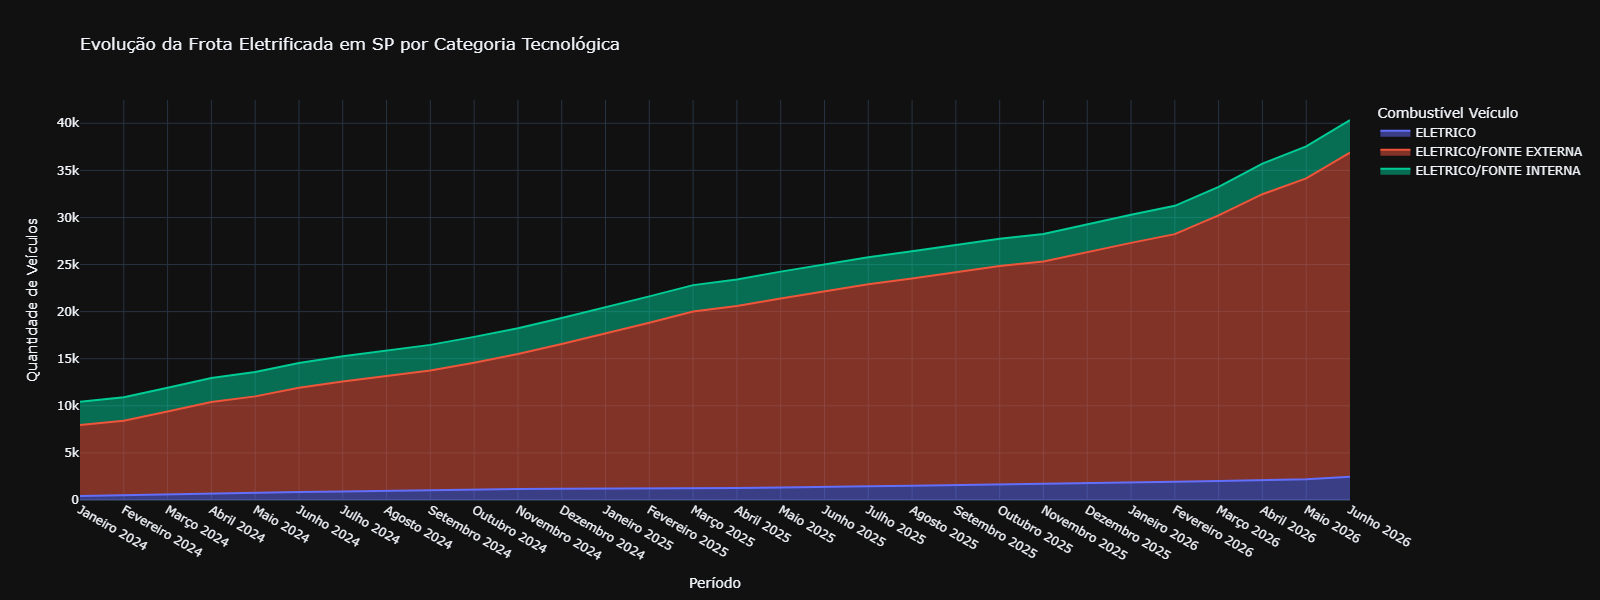

In [94]:
# Agrupamento para analisar a transição energética por categoria tecnológica
evolucao_combustivel = (
    eletricos_sp.groupby(["Ano_Ref", "Mes_Ref", "Mes_Nome", "Combustível Veículo"])["Qtd. Veículos"]
    .sum()
    .reset_index()
    .sort_values(["Ano_Ref", "Mes_Ref"])
)
evolucao_combustivel["Data"] = evolucao_combustivel["Mes_Nome"] + " " + evolucao_combustivel["Ano_Ref"].astype(str)

# Gráfico de Área Empilhada com Plotly para portfólio dinâmico
fig_comb = px.area(
    evolucao_combustivel, 
    x="Data", 
    y="Qtd. Veículos", 
    color="Combustível Veículo",
    title="Evolução da Frota Eletrificada em SP por Categoria Tecnológica",
    labels={"Qtd. Veículos": "Quantidade de Veículos", "Data": "Período"},
    template="plotly_dark",
    width=1600,  # <-- ADICIONE ESTA LINHA
    height=600   # <-- ADICIONE ESTA LINHA
)
fig_comb.update_layout(xaxis={"categoryorder": "trace"})
fig_comb.show()

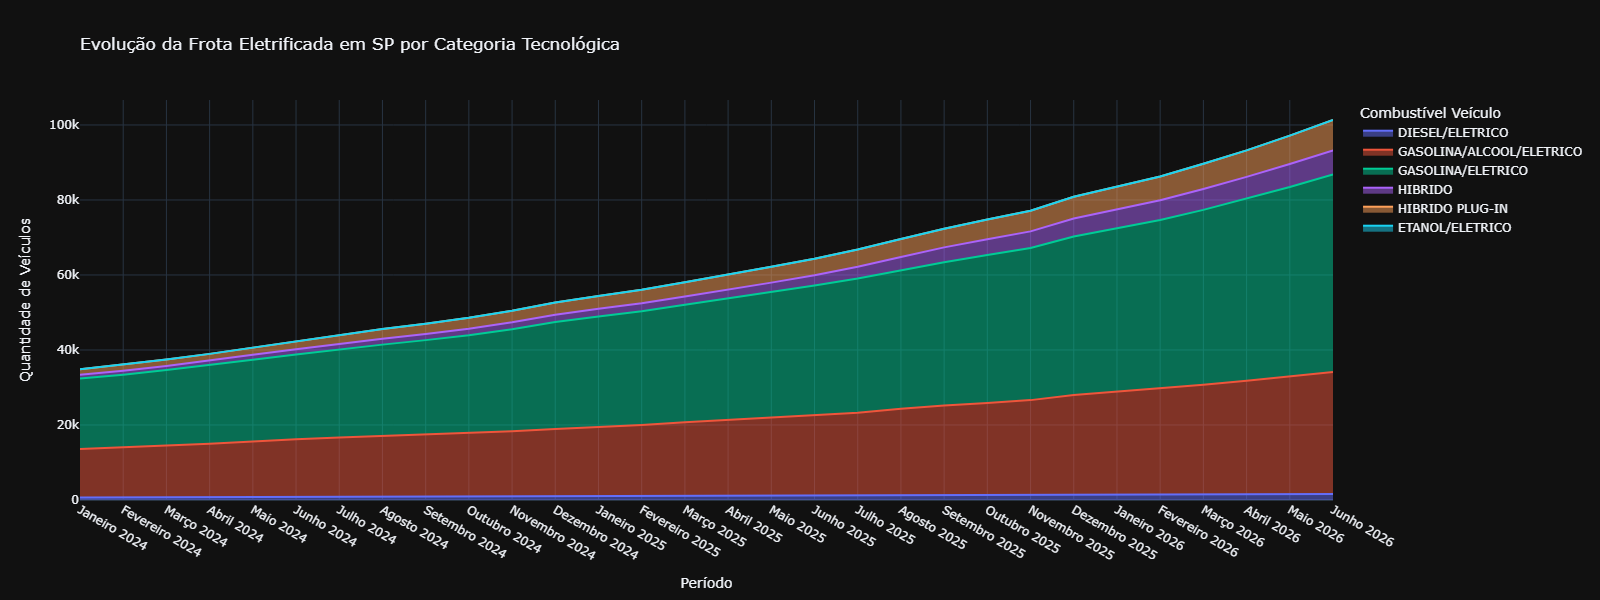

In [ ]:
# Agrupamento para analisar a transição energética por categoria tecnológica
evolucao_combustivel = (
    hibridos_sp.groupby(["Ano_Ref", "Mes_Ref", "Mes_Nome", "Combustível Veículo"])["Qtd. Veículos"]
    .sum()
    .reset_index()
    .sort_values(["Ano_Ref", "Mes_Ref"])
)
evolucao_combustivel["Data"] = evolucao_combustivel["Mes_Nome"] + " " + evolucao_combustivel["Ano_Ref"].astype(str)

# Gráfico de Área Empilhada com Plotly para portfólio dinâmico
fig_comb = px.area(
    evolucao_combustivel, 
    x="Data", 
    y="Qtd. Veículos", 
    color="Combustível Veículo",
    title="Evolução da Frota Híbrida em SP por Categoria Tecnológica",
    labels={"Qtd. Veículos": "Quantidade de Veículos", "Data": "Período"},
    template="plotly_dark",
    width=1600,  # <-- ADICIONE ESTA LINHA
    height=600   # <-- ADICIONE ESTA LINHA
)
fig_comb.update_layout(xaxis={"categoryorder": "trace"})
fig_comb.show()

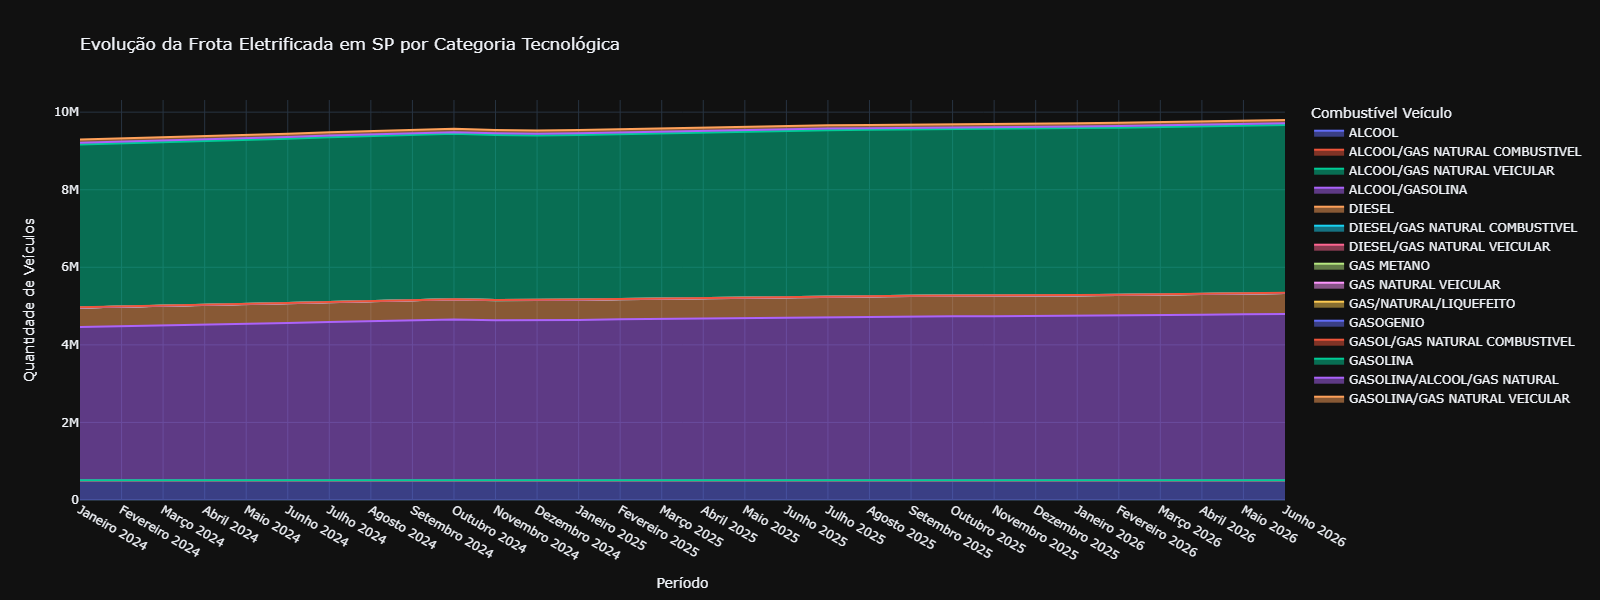

In [ ]:
# Agrupamento para analisar a transição energética por categoria tecnológica
evolucao_combustivel = (
    combustao_pura_sp.groupby(["Ano_Ref", "Mes_Ref", "Mes_Nome", "Combustível Veículo"])["Qtd. Veículos"]
    .sum()
    .reset_index()
    .sort_values(["Ano_Ref", "Mes_Ref"])
)
evolucao_combustivel["Data"] = evolucao_combustivel["Mes_Nome"] + " " + evolucao_combustivel["Ano_Ref"].astype(str)

# Gráfico de Área Empilhada com Plotly para portfólio dinâmico
fig_comb = px.area(
    evolucao_combustivel, 
    x="Data", 
    y="Qtd. Veículos", 
    color="Combustível Veículo",
    title="Evolução da Frota à combustão em SP por Categoria Tecnológica",
    labels={"Qtd. Veículos": "Quantidade de Veículos", "Data": "Período"},
    template="plotly_dark",
    width=1600,  # <-- ADICIONE ESTA LINHA
    height=600   # <-- ADICIONE ESTA LINHA
)
fig_comb.update_layout(xaxis={"categoryorder": "trace"})
fig_comb.show()

Quantidade de carros elétricos em JUN - 2026: 40349
Quantidade de carros híbridos em JUN - 2026: 101326
Quantidade de carros combustão em JUN - 2026: 9797555


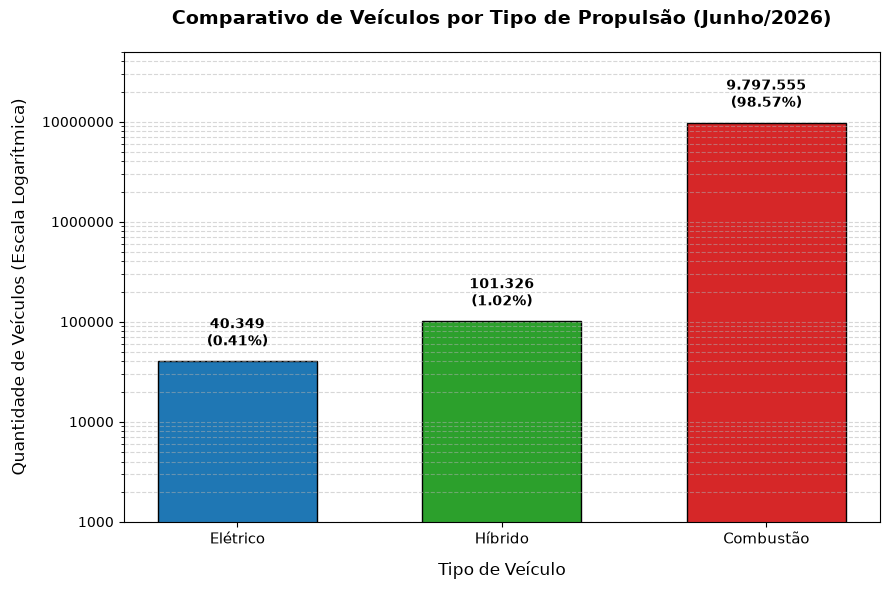

In [97]:
# Filtra Ano 2026 E Mês 1 (Janeiro)
resultado_eletrico = eletricos_sp.loc[(eletricos_sp['Ano_Ref'] == 2026) & (eletricos_sp['Mes_Ref'] == 6), 'Qtd. Veículos'].sum()
resultado_hibridos = hibridos_sp.loc[(hibridos_sp['Ano_Ref'] == 2026) & (hibridos_sp['Mes_Ref'] == 6), 'Qtd. Veículos'].sum()
resultado_combustao = combustao_pura_sp.loc[(combustao_pura_sp['Ano_Ref'] == 2026) & (combustao_pura_sp['Mes_Ref'] == 6), 'Qtd. Veículos'].sum()


print(f'Quantidade de carros elétricos em JUN - 2026: {resultado_eletrico}')
print(f'Quantidade de carros híbridos em JUN - 2026: {resultado_hibridos}')
print(f'Quantidade de carros combustão em JUN - 2026: {resultado_combustao}')

total_veiculos = resultado_eletrico + resultado_hibridos + resultado_combustao

# 1. Estrutura os dados com o cálculo da porcentagem
dados = {
    'Tipo': ['Elétrico', 'Híbrido', 'Combustão'],
    'Quantidade': [resultado_eletrico, resultado_hibridos, resultado_combustao],
    'Porcentagem': [
        (resultado_eletrico / total_veiculos) * 100,
        (resultado_hibridos / total_veiculos) * 100,
        (resultado_combustao / total_veiculos) * 100
    ]
}

df_grafico = pd.DataFrame(dados).set_index('Tipo')

# 2. Configura a figura e aplica a escala logarítmica
fig, ax = plt.subplots(figsize=(9, 6))
barras = ax.bar(df_grafico.index, df_grafico['Quantidade'], color=['#1f77b4', '#2ca02c', '#d62728'], edgecolor='black', width=0.6)

# ATENÇÃO AQUI: Escala logarítmica para deixar as barras menores visíveis
ax.set_yscale('log')

# Ajusta os limites do eixo Y para dar espaço ao texto do topo
ax.set_ylim(bottom=1000, top=50000000)

# 3. Adiciona os rótulos de texto (Quantidade + Porcentagem) em cima de cada barra
for barra, pct, qtd in zip(barras, df_grafico['Porcentagem'], df_grafico['Quantidade']):
    altura = barra.get_height()
    # Texto formatado com separador de milhar e porcentagem com duas casas decimais
    texto = f'{qtd:,}\n({pct:.2f}%)'.replace(',', '.')
    
    ax.annotate(texto,
                xy=(barra.get_x() + barra.get_width() / 2, altura),
                xytext=(0, 8),  # 8 pontos de deslocamento vertical
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# 4. Customização estética
plt.title('Comparativo de Veículos por Tipo de Propulsão (Junho/2026)', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Tipo de Veículo', fontsize=12, labelpad=10)
plt.ylabel('Quantidade de Veículos (Escala Logarítmica)', fontsize=12, labelpad=10)
plt.xticks(rotation=0, fontsize=11)

# Remove notação científica confusa do eixo Y e formata os números de forma limpa
from matplotlib.ticker import ScalarFormatter
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style='plain', axis='y')
plt.grid(axis='y', linestyle='--', alpha=0.5, which='both')

plt.tight_layout()
plt.show()

## 4. Modelo Preditivo (Forecasting até Dezembro de 2027)

In [98]:
# Preparando os dados para a regressão (Tempo vira um índice numérico incremental 1, 2, 3...)
evolucao_geral_eletrico["Timeline_Index"] = range(1, len(evolucao_geral_eletrico) + 1)

X = evolucao_geral_eletrico[["Timeline_Index"]].values
y = evolucao_geral_eletrico["Qtd. Veículos"].values

# Treinando o modelo
modelo = LinearRegression()
modelo.fit(X, y)

# Projetando os próximos meses até Dezembro de 2027
ultimo_index = evolucao_geral_eletrico["Timeline_Index"].max()
# Assumindo que o último dado coletado foi Junho de 2026 (Index 30), criamos mais 18 meses
meses_projeção = 18
futuro_index = np.arange(ultimo_index + 1, ultimo_index + 1 + meses_projeção).reshape(-1, 1)
predicoes_futuras = modelo.predict(futuro_index)

# Criando dataframe com as projeções
datas_futuras = [
    "Jul 2026", "Ago 2026", "Set 2026", "Out 2026", "Nov 2026", "Dez 2026",
    "Jan 2027", "Fev 2027", "Mar 2027", "Abr 2027", "Mai 2027", "Jun 2027",
    "Jul 2027", "Ago 2027", "Set 2027", "Out 2027", "Nov 2027", "Dez 2027"
]
df_projeção = pd.DataFrame({
    "Data": datas_futuras,
    "Qtd. Veículos": predicoes_futuras,
    "Tipo": "Projeção (Modelo Linear)"
})

df_real = pd.DataFrame({
    "Data": evolucao_geral_eletrico["Mes_Nome"].str[:3] + " " + evolucao_geral_eletrico["Ano_Ref"].astype(str),
    "Qtd. Veículos": y,
    "Tipo": "Dado Histórico (Senatran)"
})

df_fused_eletrico = pd.concat([df_real, df_projeção], ignore_index=True)

In [99]:
# Preparando os dados para a regressão (Tempo vira um índice numérico incremental 1, 2, 3...)
evolucao_geral_hibridos["Timeline_Index"] = range(1, len(evolucao_geral_hibridos) + 1)

X = evolucao_geral_hibridos[["Timeline_Index"]].values
y = evolucao_geral_hibridos["Qtd. Veículos"].values

# Treinando o modelo
modelo = LinearRegression()
modelo.fit(X, y)

# Projetando os próximos meses até Dezembro de 2027
ultimo_index = evolucao_geral_hibridos["Timeline_Index"].max()
# Assumindo que o último dado coletado foi Junho de 2026 (Index 30), criamos mais 18 meses
meses_projeção = 18
futuro_index = np.arange(ultimo_index + 1, ultimo_index + 1 + meses_projeção).reshape(-1, 1)
predicoes_futuras = modelo.predict(futuro_index)

# Criando dataframe com as projeções
datas_futuras = [
    "Jul 2026", "Ago 2026", "Set 2026", "Out 2026", "Nov 2026", "Dez 2026",
    "Jan 2027", "Fev 2027", "Mar 2027", "Abr 2027", "Mai 2027", "Jun 2027",
    "Jul 2027", "Ago 2027", "Set 2027", "Out 2027", "Nov 2027", "Dez 2027"
]
df_projeção = pd.DataFrame({
    "Data": datas_futuras,
    "Qtd. Veículos": predicoes_futuras,
    "Tipo": "Projeção (Modelo Linear)"
})

df_real = pd.DataFrame({
    "Data": evolucao_geral_hibridos["Mes_Nome"].str[:3] + " " + evolucao_geral_hibridos["Ano_Ref"].astype(str),
    "Qtd. Veículos": y,
    "Tipo": "Dado Histórico (Senatran)"
})

df_fused_hibrido = pd.concat([df_real, df_projeção], ignore_index=True)

In [100]:
# Preparando os dados para a regressão (Tempo vira um índice numérico incremental 1, 2, 3...)
evolucao_geral_combustao["Timeline_Index"] = range(1, len(evolucao_geral_combustao) + 1)

X = evolucao_geral_combustao[["Timeline_Index"]].values
y = evolucao_geral_combustao["Qtd. Veículos"].values

# Treinando o modelo
modelo = LinearRegression()
modelo.fit(X, y)

# Projetando os próximos meses até Dezembro de 2027
ultimo_index = evolucao_geral_combustao["Timeline_Index"].max()
# Assumindo que o último dado coletado foi Junho de 2026 (Index 30), criamos mais 18 meses
meses_projeção = 18
futuro_index = np.arange(ultimo_index + 1, ultimo_index + 1 + meses_projeção).reshape(-1, 1)
predicoes_futuras = modelo.predict(futuro_index)

# Criando dataframe com as projeções
datas_futuras = [
    "Jul 2026", "Ago 2026", "Set 2026", "Out 2026", "Nov 2026", "Dez 2026",
    "Jan 2027", "Fev 2027", "Mar 2027", "Abr 2027", "Mai 2027", "Jun 2027",
    "Jul 2027", "Ago 2027", "Set 2027", "Out 2027", "Nov 2027", "Dez 2027"
]
df_projeção = pd.DataFrame({
    "Data": datas_futuras,
    "Qtd. Veículos": predicoes_futuras,
    "Tipo": "Projeção (Modelo Linear)"
})

df_real = pd.DataFrame({
    "Data": evolucao_geral_combustao["Mes_Nome"].str[:3] + " " + evolucao_geral_combustao["Ano_Ref"].astype(str),
    "Qtd. Veículos": y,
    "Tipo": "Dado Histórico (Senatran)"
})

df_fused_combustão = pd.concat([df_real, df_projeção], ignore_index=True)

## 5. Visualização do Modelo de Previsão de Demanda

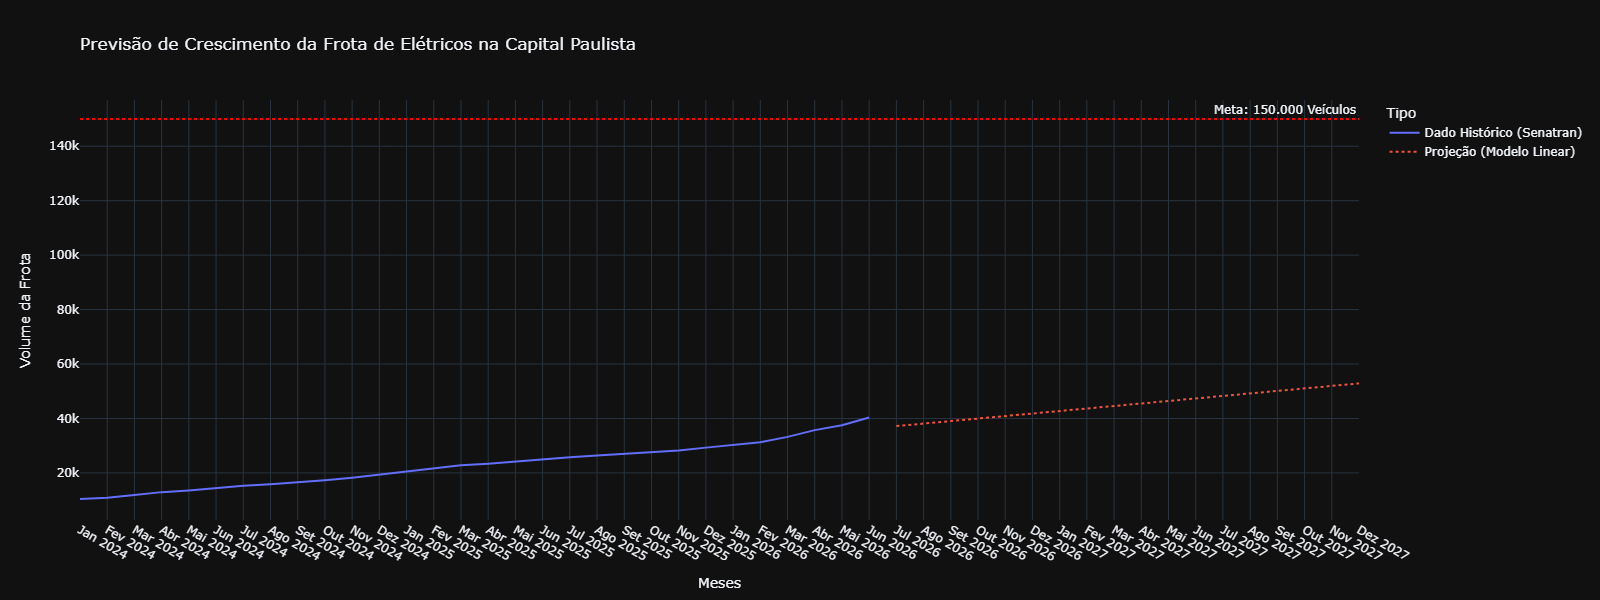

In [101]:
fig_pred = px.line(
    df_fused_eletrico, 
    x="Data", 
    y="Qtd. Veículos", 
    color="Tipo",
    title="Previsão de Crescimento da Frota de Elétricos na Capital Paulista",
    labels={"Qtd. Veículos": "Volume da Frota", "Data": "Meses"},
    line_dash="Tipo",
    template="plotly_dark",
    width=1600,  # <-- ADICIONE ESTA LINHA
    height=600   # <-- ADICIONE ESTA LINHA
)

# Destacando o marco onde a frota ultrapassará 150 mil veículos
fig_pred.add_hline(y=150000, line_dash="dot", line_color="red", annotation_text="Meta: 150.000 Veículos")
fig_pred.show()

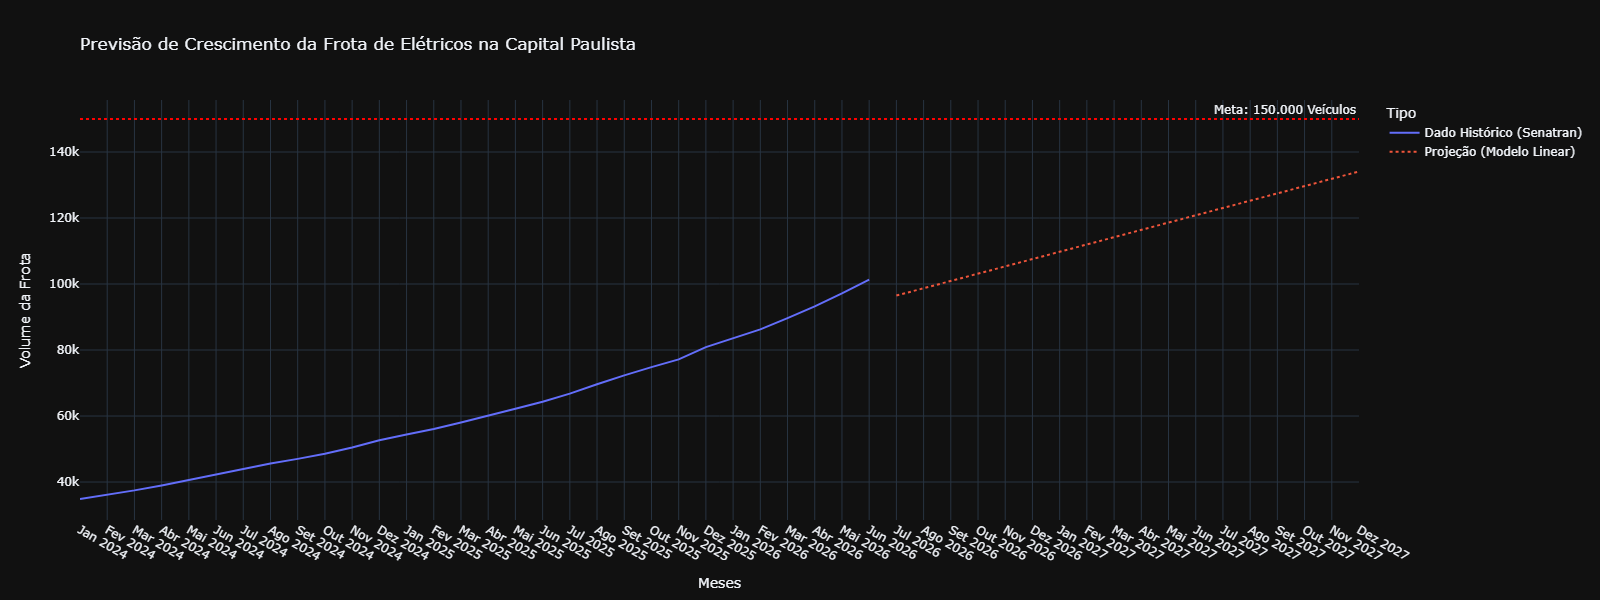

In [102]:
fig_pred = px.line(
    df_fused_hibrido, 
    x="Data", 
    y="Qtd. Veículos", 
    color="Tipo",
    title="Previsão de Crescimento da Frota de Elétricos na Capital Paulista",
    labels={"Qtd. Veículos": "Volume da Frota", "Data": "Meses"},
    line_dash="Tipo",
    template="plotly_dark",
    width=1600,  # <-- ADICIONE ESTA LINHA
    height=600   # <-- ADICIONE ESTA LINHA
)

# Destacando o marco onde a frota ultrapassará 150 mil veículos
fig_pred.add_hline(y=150000, line_dash="dot", line_color="red", annotation_text="Meta: 150.000 Veículos")
fig_pred.show()

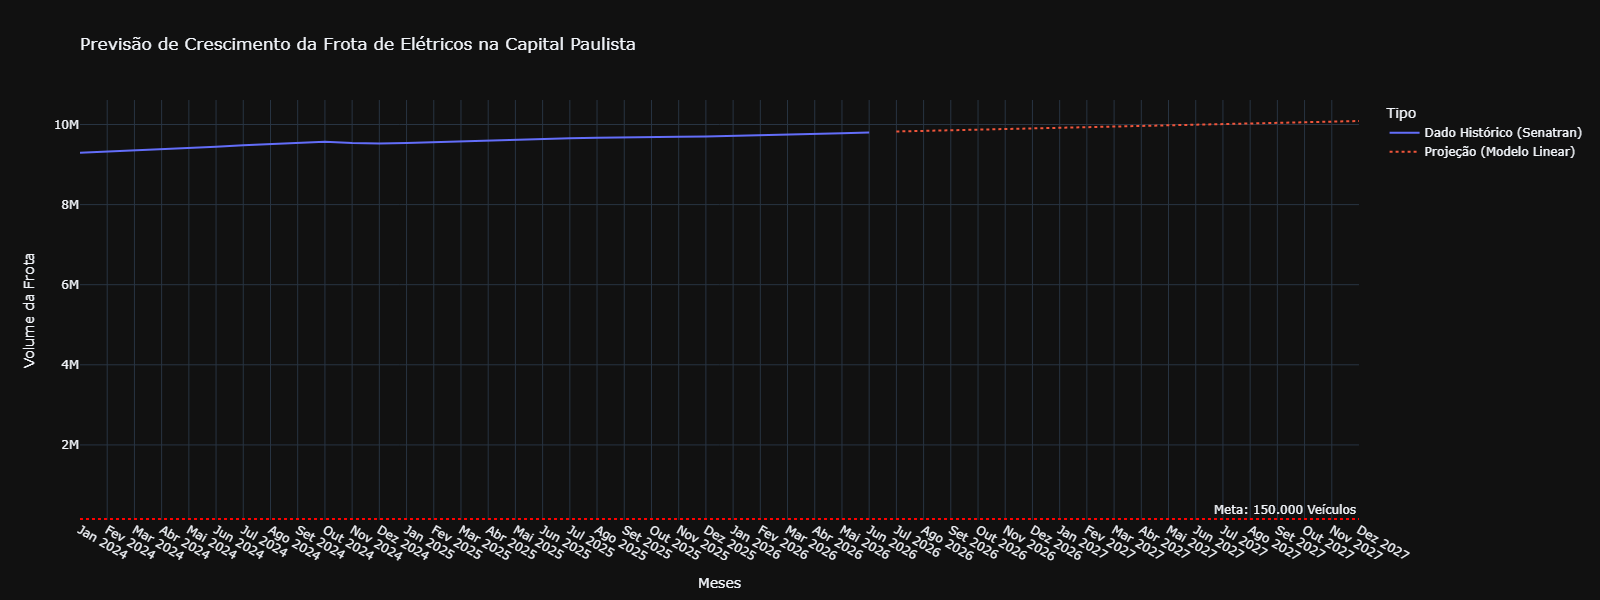

In [103]:
fig_pred = px.line(
    df_fused_combustão, 
    x="Data", 
    y="Qtd. Veículos", 
    color="Tipo",
    title="Previsão de Crescimento da Frota de Elétricos na Capital Paulista",
    labels={"Qtd. Veículos": "Volume da Frota", "Data": "Meses"},
    line_dash="Tipo",
    template="plotly_dark",
    width=1600,  # <-- ADICIONE ESTA LINHA
    height=600   # <-- ADICIONE ESTA LINHA
)

# Destacando o marco onde a frota ultrapassará 150 mil veículos
fig_pred.add_hline(y=150000, line_dash="dot", line_color="red", annotation_text="Meta: 150.000 Veículos")
fig_pred.show()

## 🏁 Conclusão da Análise Exploratória & Próximos Passos

### 📊 Principais Descobertas (Insights de Negócio)
1. **Crescimento Exponencial:** A frota de veículos elétricos e híbridos na cidade de São Paulo triplicou no intervalo analisado, saltando de **~31k (Jan/2024)** para **~107k (Jun/2026)**. Isso mostra que a adoção local está acontecendo de forma extremamente agressiva.
2. **Velocidade de Mercado:** Os cálculos de variação **YoY (Ano contra Ano)** indicam que o mercado não está apenas crescendo, mas acelerando o ritmo de novas aquisições a cada ano.
3. **Padrão de Transição:** Os veículos híbridos ainda representam o volume principal por conta da flexibilidade de abastecimento, mas a inclinação da curva dos elétricos puros (BEV) vem ganhando força à medida que infraestruturas privadas (prédios e shoppings) se expandem.

### 🔮 O Impacto do Modelo Preditivo
* O modelo de **Forecasting** sinaliza que o município de São Paulo romperá a barreira histórica de **150.000 veículos eletrificados circulando em 2027**.
* **Impacto Real:** Esse número acende um alerta para o ecossistema de mobilidade urbana (concessionárias de energia e redes de eletropostos). A velocidade de instalação de carregadores rápidos de rua precisará acelerar para evitar o estrangulamento e filas nos pontos de recarga públicos.

---

### 🚀 Próximos Passos para o Projeto (`02_modeling.ipynb`)
Para evoluir esta análise para um modelo de Machine Learning ainda mais robusto para o portfólio, os próximos passos sugeridos são:
* [ ] **Testar Modelos Não-Lineares:** Avaliar regressões polinomiais ou modelos específicos de séries temporais (como ARIMA ou Prophet) para capturar possíveis sazonalidades de fim de ano nas vendas.
* [ ] **Cruzamento de Dados Externos:** Adicionar variáveis explicativas externas (como histórico de preços de combustíveis fósseis ou volume de incentivos fiscais liberados na capital) para enriquecer os recursos (*feature engineering*) do modelo.